In [2]:
# Adding other strokes to create separate regression lines

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error

In [4]:
#Load data
races = pd.read_csv("Nemo.csv")
forcedecks   = pd.read_csv("Forcedeck.csv")

#Extract CMJ rows only
fd_cmj = forcedecks[forcedecks["Test Type"] == "CMJ"].copy()

In [12]:
#Extract columns

RACE_NAME_COL = "AthleteName"       # name column in races
CMJ_NAME_COL  = "About"       # name column in cmj
RACE_DATE     = "Date"               # date column in races
CMJ_DATE      = "Date"               # date column in cmj
EVENT_COL     = "RaceEventName"              # event name column in races
TIME_COL      = "Lap1_15mElapsedTime"           # race time column
CMJ_COL       = "Peak Power / BM [W/kg]"     # CMJ result column
POOL_COL = "PoolLength"    # pool length column
SEX_COL = "AthleteGenderName" 
POOL_LENGTH = 50   #long course
TOLERANCE = pd.Timedelta("90 days")

STROKES = ["50 m Freestyle", "50 m Backstroke", "50 m Breaststroke", "50 m Butterfly"]

#Ensure every stroke is a different colour to identify each regression line
STROKE_COLOURS = {
    "50 m Freestyle":    "#2E86AB",
    "50 m Backstroke":   "#E84855",
    "50 m Breaststroke": "#F4A261",
    "50 m Butterfly":    "#57CC99"
}

In [13]:
#Standardise athlete names for matching
races["athlete_id"] = races[RACE_NAME_COL].str.lower().str.strip()
fd_cmj["athlete_id"]   = fd_cmj[CMJ_NAME_COL].str.lower().str.strip()

#Convert dates
races[RACE_DATE] = pd.to_datetime(races[RACE_DATE], dayfirst = True)
fd_cmj[CMJ_DATE]    = pd.to_datetime(fd_cmj[CMJ_DATE], dayfirst = True)

# Filter to all four 50m strokes and CMJ date window
races_50m = races[races[EVENT_COL].isin(STROKES)].copy()
races_50m = races_50m[races_50m[RACE_DATE] >= "2023-10-01"].copy()

print("Races per stroke:")
print(races_50m[EVENT_COL].value_counts())
print(f"\nUnique athletes in races: {races_50m['athlete_id'].nunique()}")
print(f"Unique athletes in CMJ:   {fd_cmj['athlete_id'].nunique()}")

Races per stroke:
RaceEventName
50 m Butterfly       62
50 m Backstroke      46
50 m Breaststroke    44
50 m Freestyle       43
Name: count, dtype: int64

Unique athletes in races: 18
Unique athletes in CMJ:   11


In [14]:
races_50m = races_50m.sort_values(RACE_DATE)
fd_cmj = fd_cmj.sort_values(CMJ_DATE)

df = pd.merge_asof(
    races_50m,
    fd_cmj,
    left_on=RACE_DATE,
    right_on=CMJ_DATE,
    by="athlete_id",
    direction="nearest",
    tolerance=TOLERANCE,
    suffixes=("_race", "_cmj")
)

#Drop rows where no CMJ fell within the tolerance window
df = df.dropna(subset=[CMJ_COL])

print(f"Valid race–CMJ pairings: {len(df)}")
print(f"Unique athletes matched: {df['athlete_id'].nunique()}")
print("\nPairings per stroke:")
print(df[EVENT_COL].value_counts())

Valid race–CMJ pairings: 82
Unique athletes matched: 9

Pairings per stroke:
RaceEventName
50 m Butterfly       41
50 m Breaststroke    20
50 m Backstroke      14
50 m Freestyle        7
Name: count, dtype: int64


In [18]:
#select only the three columns we need for the analysis
#drop any rows where one on the values is missing
df_clean = df[[EVENT_COL, CMJ_COL, TIME_COL]].dropna()

print(f"Final sample size: {len(df_clean)}")

#spot any obvious outliers before we fit the model
print(df_clean.describe())

# Remove any rows where race time is zero
df_clean = df_clean[df_clean[TIME_COL] > 0]

print(f"Sample size: {len(df_clean)}")

Final sample size: 56
       Peak Power / BM [W/kg]  Lap1_15mElapsedTime
count               56.000000            56.000000
mean                50.173821             6.899107
std                  6.462648             0.845670
min                 36.334000             5.420000
25%                 47.482000             6.470000
50%                 52.240000             6.610000
75%                 54.677750             7.645000
max                 57.089000             8.200000
Sample size: 56


In [19]:
#store fitted models in a dictionary
models = {}

# Loop through each stroke one by one
for stroke in STROKES:
    
    #subset the clean dataframe to just strokes
    subset = df_clean[df_clean[EVENT_COL] == stroke]
    
    #minimum of 3 data points to proceed to avoid small sample size
    if len(subset) < 3:
        print(f"Skipping {stroke} — not enough data (n={len(subset)})\n")
        continue
    
    # X_s = predictor variable
    # y_s = outcome variable
    X_s = subset[[CMJ_COL]].values
    y_s = subset[TIME_COL].values
    
    #sample is small, train/test split would leave too few test points
    #Leave on out trains on n-1 athletes and tests on the one left out
    loo = LeaveOneOut()
    m = LinearRegression()
    y_pred_loo = cross_val_predict(m, X_s, y_s, cv=loo)
    
    #Fit the model on the data
    m.fit(X_s, y_s)
    models[stroke] = m
    
    #Evaluation metrics
    r2 = r2_score(y_s, y_pred_loo)
    
    rmse = np.sqrt(mean_squared_error(y_s, y_pred_loo))
    
    #summary of stroke
    #negative slope = higher CMJ -> faster time
    
    print(f"--- {stroke} (n={len(subset)}) ---")
    print(f"  Slope : {m.coef_[0]:.4f}  |  Intercept: {m.intercept_:.4f}")
    print(f"  LOOCV R²: {r2:.3f}  |  RMSE: {rmse:.3f}s\n")

--- 50 m Freestyle (n=4) ---
  Slope : -0.0651  |  Intercept: 9.1110
  LOOCV R²: 0.944  |  RMSE: 0.108s

--- 50 m Backstroke (n=8) ---
  Slope : 0.0401  |  Intercept: 6.5651
  LOOCV R²: -1.336  |  RMSE: 0.140s

--- 50 m Breaststroke (n=16) ---
  Slope : 0.0343  |  Intercept: 5.7596
  LOOCV R²: 0.017  |  RMSE: 0.133s

--- 50 m Butterfly (n=28) ---
  Slope : -0.0460  |  Intercept: 8.6597
  LOOCV R²: 0.015  |  RMSE: 0.426s



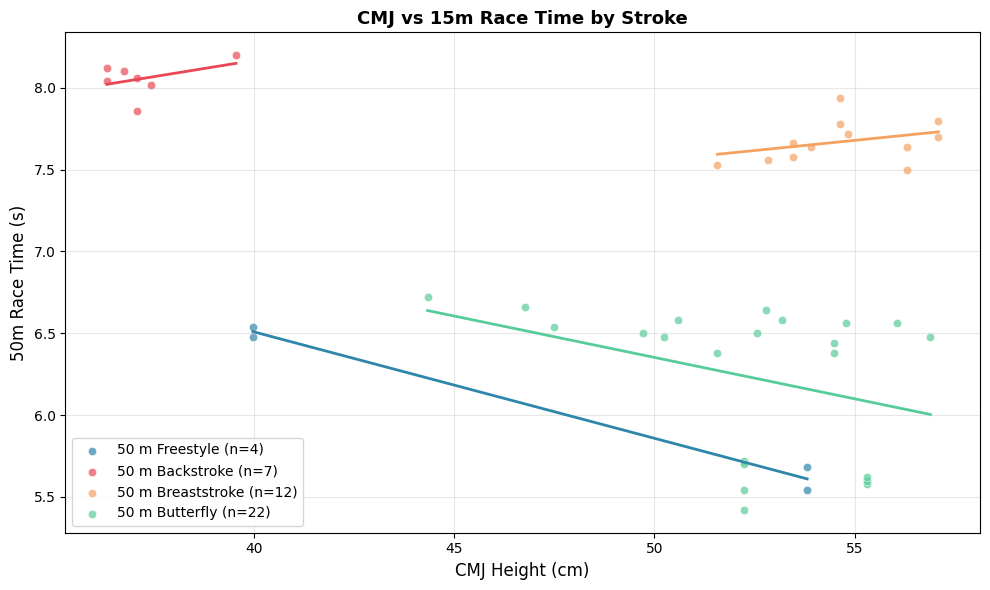

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

for stroke, colour in STROKE_COLOURS.items():
    if stroke not in models:
        continue
    
    subset = df_clean[df_clean[EVENT_COL] == stroke]
    X_s    = subset[[CMJ_COL]].values
    y_s    = subset[TIME_COL].values
    m      = models[stroke]
    
    # Scatter points
    ax.scatter(
        X_s, y_s,
        color=colour, alpha=0.7, edgecolors="white",
        linewidths=0.5, label=f"{stroke} (n={len(subset)})"
    )
    
    # Regression line
    x_line = np.linspace(X_s.min(), X_s.max(), 200).reshape(-1, 1)
    ax.plot(x_line, m.predict(x_line), color=colour, linewidth=2)

ax.set_xlabel("CMJ Height (cm)", fontsize=12)
ax.set_ylabel("50m Race Time (s)", fontsize=12)
ax.set_title("CMJ vs 15m Race Time by Stroke", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cmj_vs_15m_all_strokes.png", dpi=150)
plt.show()